# **Silicon Thermals - Overview**

This project implements a Multilayer Perceptron (MLP) to predict the real-time thermal behavior of a Raspberry Pi System-on-Chip (SoC). Unlike static thresholds, this model learns the non-linear relationship between CPU utilization, clock frequency, and RAM pressure to forecast heat generation.

In [3]:
# Importing all neccessities and requirements
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [5]:
# Loading the training dataset. (The training dataset is available at the github repo.. The data was collected from a Raspberry Pi 5 by running thermal recording scripts over a period of time.)
file_path = 'pi_thermal_data.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {len(df)} rows of data.")
    print(df.head())
except FileNotFoundError:
    print("Error: 'pi_thermal_data.csv' not found. Please upload it to the 'Files' tab on the left.")

Successfully loaded 756 rows of data.
      timestamp  cpu_usage  cpu_freq  ram_usage   temp
0  1.777808e+09        0.2    2400.0       13.7  44.65
1  1.777808e+09        0.0    2400.0       13.7  46.30
2  1.777808e+09        0.0    2400.0       13.7  45.20
3  1.777809e+09        0.0    2400.0       13.7  46.30
4  1.777809e+09        0.2    2400.0       13.7  45.20


In [6]:
# Data Preprocessing
X = df[['cpu_usage', 'cpu_freq', 'ram_usage']].values
y = df['temp'].values.reshape(-1, 1)


scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Splitting 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [7]:
# Building the model using nn.Module class and ReLu as the working algo.
class ThermalMLP(nn.Module):
    def __init__(self):
        super(ThermalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

model = ThermalMLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
#Training the model on the dataset.
epochs = 3000
losses = []

for epoch in range(epochs):
    # Forward Pass
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    # Backward Pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.6f}')

Epoch [50/3000] - Loss: 0.192856
Epoch [100/3000] - Loss: 0.175162
Epoch [150/3000] - Loss: 0.170784
Epoch [200/3000] - Loss: 0.168538
Epoch [250/3000] - Loss: 0.167148
Epoch [300/3000] - Loss: 0.165854
Epoch [350/3000] - Loss: 0.164796
Epoch [400/3000] - Loss: 0.163942
Epoch [450/3000] - Loss: 0.163158
Epoch [500/3000] - Loss: 0.162258
Epoch [550/3000] - Loss: 0.160914
Epoch [600/3000] - Loss: 0.161169
Epoch [650/3000] - Loss: 0.159176
Epoch [700/3000] - Loss: 0.158131
Epoch [750/3000] - Loss: 0.157199
Epoch [800/3000] - Loss: 0.156649
Epoch [850/3000] - Loss: 0.155571
Epoch [900/3000] - Loss: 0.155031
Epoch [950/3000] - Loss: 0.154426
Epoch [1000/3000] - Loss: 0.154255
Epoch [1050/3000] - Loss: 0.153415
Epoch [1100/3000] - Loss: 0.153392
Epoch [1150/3000] - Loss: 0.152928
Epoch [1200/3000] - Loss: 0.152559
Epoch [1250/3000] - Loss: 0.152469
Epoch [1300/3000] - Loss: 0.152420
Epoch [1350/3000] - Loss: 0.152765
Epoch [1400/3000] - Loss: 0.152343
Epoch [1450/3000] - Loss: 0.152479
Epoch

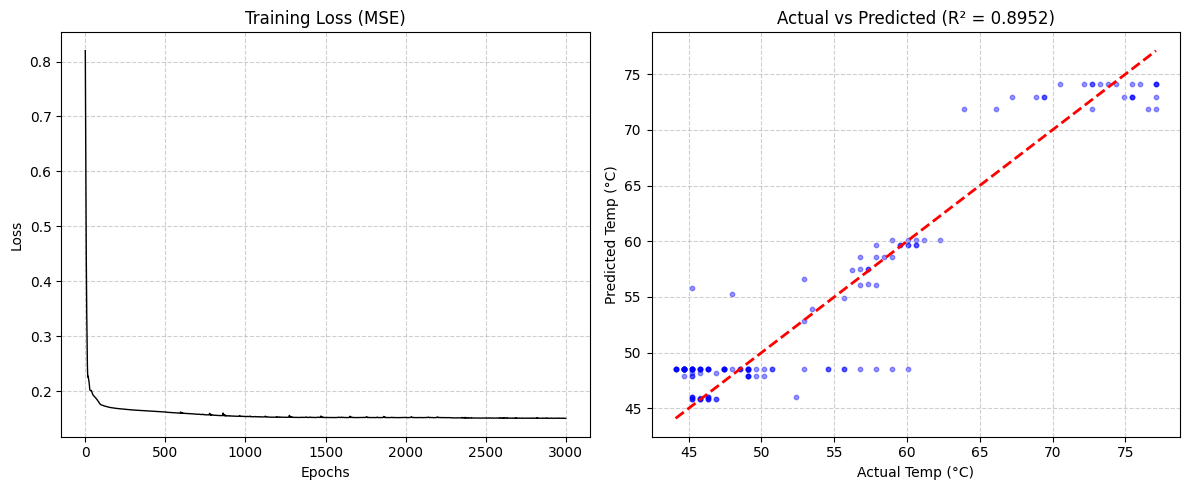

In [9]:
# Testing the model on the testing split of the original dataset.
model.eval()
with torch.no_grad():
    test_predictions_scaled = model(X_test)
    # Un-scale the data to get actual Celsius values back
    test_predictions = scaler_y.inverse_transform(test_predictions_scaled)
    y_actual = scaler_y.inverse_transform(y_test)

# Calculate R-Squared (Accuracy)
score = r2_score(y_actual, test_predictions)

# Plot 1: Training Loss Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses, color='black', linewidth=1)
plt.title('Training Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_actual, test_predictions, alpha=0.4, color='blue', s=10)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted (R² = {score:.4f})')
plt.xlabel('Actual Temp (°C)')
plt.ylabel('Predicted Temp (°C)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [13]:
def predict_pi_temp(usage, freq, ram):
    model.eval()
    with torch.no_grad():
        input_data = scaler_x.transform([[usage, freq, ram]])
        input_tensor = torch.FloatTensor(input_data)
        pred_scaled = model(input_tensor)
        prediction = scaler_y.inverse_transform(pred_scaled)
        return prediction[0][0]

print(f"\n--- Model Ready ---")
sample_temp = predict_pi_temp(100, 1500, 50) # Example: 100% CPU at Max Freq
print(f"Predicted temperature for 100% load: {sample_temp:.2f}°C")


--- Model Ready ---
Predicted temperature for 100% load: -16.11°C
